In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chisquare
import pymc as pm
import pytensor
import arviz as az
pytensor.config.cxx = '/usr/bin/clang++'

In [2]:
df = pd.read_csv('gl2025.txt', header = None)
home_teams = df.iloc[:,[0,6,8,53]]
away_teams = df.iloc[:,[0,3,5,25]]
home_teams = home_teams.rename({0:'Date',6:'Team',8:'Game_Num',53:'HR'},axis = 1)
away_teams = away_teams.rename({0:'Date',3:'Team',5:'Game_Num',25:'HR'},axis = 1)
games = pd.concat([home_teams,away_teams],ignore_index=True)

In [3]:
Guards_2025 = games[games["Team"]=="CLE"]
Guards_2025 = Guards_2025.sort_values(by = 'Game_Num')
Guards_2025["HR"].describe()
Guards_2025.loc[:,"Group"] = "2025 - Full Season"

Text(0, 0.5, 'Number of Games')

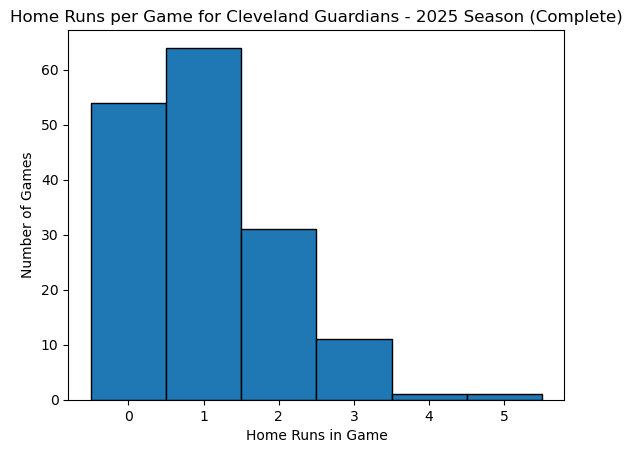

In [4]:
plt.hist(Guards_2025["HR"], align = 'left', bins =  np.arange(0, Guards_2025["HR"].max() + 2),edgecolor = 'black')
plt.title("Home Runs per Game for Cleveland Guardians - 2025 Season (Complete)")
plt.xlabel("Home Runs in Game")
plt.ylabel("Number of Games")

In [5]:
Guards_First42 = Guards_2025[Guards_2025["Game_Num"]<=42]
Guards_First42.loc[:,"Group"] = "2025 - First 42 Games"

In [6]:
df = pd.read_csv('gl2024.txt', header = None)
home_teams = df.iloc[:,[0,6,8,53]]
away_teams = df.iloc[:,[0,3,5,25]]
home_teams = home_teams.rename({0:'Date',6:'Team',8:'Game_Num',53:'HR'},axis = 1)
away_teams = away_teams.rename({0:'Date',3:'Team',5:'Game_Num',25:'HR'},axis = 1)
games = pd.concat([home_teams,away_teams],ignore_index=True)
Guards_2024 = games[games["Team"]=="CLE"]
Guards_2024 = Guards_2024.sort_values(by = 'Game_Num')
Guards_2024["HR"].describe()
Guards_2024.loc[:,"Group"] = "2024 - Full Season"

Text(0.5, 1.0, 'Home Runs per Game for Cleveland Guardians\n 2024 Full Season, 2025 First 42 Games, and 2025 Full Season')

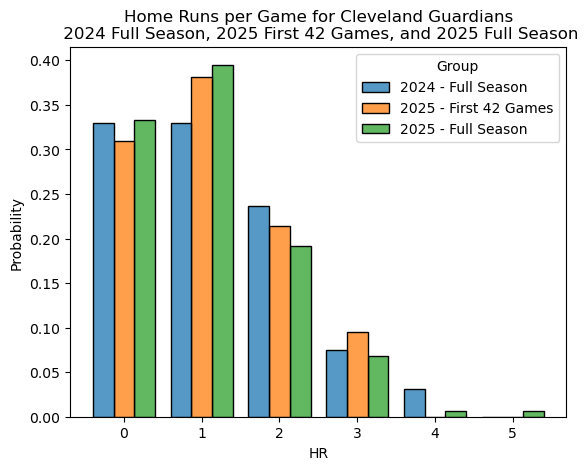

In [7]:
df = pd.concat([Guards_2024,Guards_First42,Guards_2025],ignore_index=True)
sns.histplot(data = df, x = "HR", stat = "probability",hue = "Group", common_norm = False, multiple = "dodge", shrink = 0.8, bins = np.arange(-0.5, df["HR"].max() + 1.5), edgecolor = 'black')
plt.title("Home Runs per Game for Cleveland Guardians\n 2024 Full Season, 2025 First 42 Games, and 2025 Full Season")

In [8]:
summary_stats = df.groupby("Group")["HR"].agg(['mean','std'])

In [9]:
summary_stats

,mean,std
Group,,
2024 - Full Season,1.149068,1.061904
2025 - First 42 Games,1.095238,0.957882
2025 - Full Season,1.037037,0.977313


Text(0.5, 1.0, 'Home Runs per Game for Cleveland Guardians - 2025 Season\n Post-42 Game Prediction vs Observed Counts')

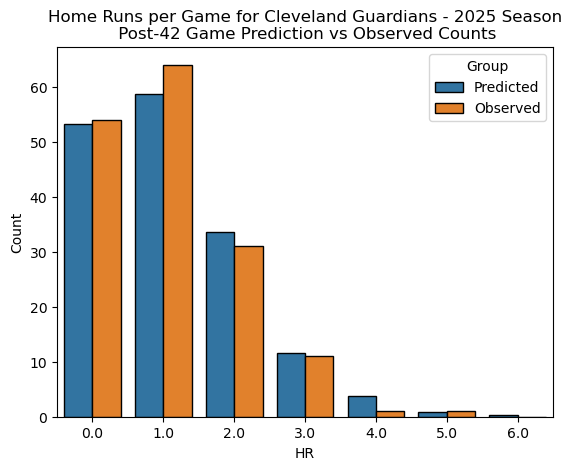

In [35]:
proportions = [.328,.36225,.20775,.072,.023,.00525,.00175]
Pred_Eval = pd.DataFrame(data = [[0,1,2,3,4,5,6],proportions]).T.rename({0:'HR',1:'Predicted'},axis = 1)
Pred_Eval.loc[:,"Predicted"] = Pred_Eval["Predicted"] * 162
Pred_Eval.loc[:,"Observed"] = Guards_2025["HR"].value_counts().sort_index().reindex(Pred_Eval["HR"], fill_value = 0).values
Pred_Eval = Pred_Eval.melt(id_vars = ['HR'], value_vars = ['Predicted','Observed'], var_name = 'Group', value_name = 'Count')
sns.barplot(data = Pred_Eval, x = "HR", y = "Count", hue = "Group", edgecolor = 'black')
plt.title("Home Runs per Game for Cleveland Guardians - 2025 Season\n Post-42 Game Prediction vs Observed Counts")

In [14]:
basic_model = pm.Model()
with basic_model:
    lambdah = pm.Gamma("lambdah",alpha = 16, beta = 14)
    Y_obs = pm.Poisson("Y_obs",mu = lambdah,observed = Guards_2025.loc[:,"HR"])
    Y_pred = pm.Poisson("Y_pred",mu = lambdah)
    idata = pm.sample(random_seed=17)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [lambdah]
>Metropolis: [Y_pred]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [17]:
pm.summary(idata,var_names=["lambdah"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambdah,1.046,0.077,0.891,1.194,0.002,0.001,1440.0,2646.0,1.0
